# Module 3D — Battery State-of-Health Regression (Local Training)

Train a leakage-safe XGBoost model on `EV_Battery_Dataset_1.csv`.

- Target: `SOH_pct`
- Features: cycle, voltage, current, temperature, and discharge time
- Artifact: `ml/models/battery_soh_xgb.joblib`

`Capacity_Ah` is deliberately excluded because `SOH_pct` is calculated directly from capacity; including it would leak the answer. EVIoT SoH is not used because profiling found no relationship between its SoH target and battery telemetry.

Evaluation uses a chronological split to test future-cycle degradation rather than easy random interpolation.

In [ ]:
# Run once if dependencies are missing:
# %pip install -r ../apps/backend/requirements-phase3.txt

from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Repository:", REPO_ROOT)
print("Python:", sys.version)

Repository: F:\BMW
Python: 3.12.8 (tags/v3.12.8:2dc476b, Dec  3 2024, 19:30:04) [MSC v.1942 64 bit (AMD64)]


In [ ]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import xgboost
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

from ml.predictive_maintenance.config import (
    BATTERY_SOH_FEATURES,
    BATTERY_SOH_MODEL_PATH,
    BATTERY_SOH_PATH,
)
from ml.predictive_maintenance.datasets import prepare_battery_cycle_frame

RANDOM_STATE = 42
MAX_TEST_MAE_PCT = 3.0
MIN_BASELINE_IMPROVEMENT = 0.10

print("Dataset:", BATTERY_SOH_PATH)
print("Artifact:", BATTERY_SOH_MODEL_PATH)
print("xgboost:", xgboost.__version__, "sklearn:", sklearn.__version__)

Dataset: F:\BMW\data\predictive_maintenance\EV_Battery_Dataset_1.csv
Artifact: F:\BMW\ml\models\battery_soh_xgb.joblib
xgboost: 3.3.0 sklearn: 1.9.0


Rows: 1,500
Features: ['Cycle', 'Voltage_V', 'Current_A', 'Temperature_C', 'Time_s']


,count,mean,std,min,25%,50%,75%,max
Cycle,1500.0,750.500000,433.157015,1.000,375.75000,750.500,1125.250,1500.000
Voltage_V,1500.0,4.087492,0.065150,3.968,4.03175,4.088,4.144,4.206
Current_A,1500.0,1.497811,0.050800,1.350,1.46300,1.499,1.531,1.662
Temperature_C,1500.0,28.736160,2.209156,24.170,26.85500,28.730,30.625,33.410
Time_s,1500.0,4219.761867,355.040433,3537.900,3941.75000,4155.550,4468.150,5416.000
SOH_pct,1500.0,85.553533,6.599971,75.920,79.88000,84.100,90.725,100.620


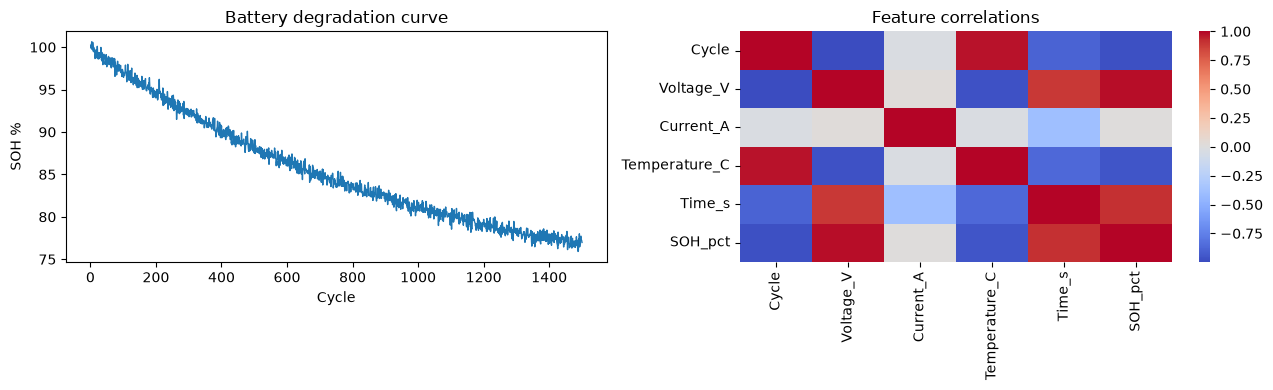

In [ ]:
data = prepare_battery_cycle_frame()
frame = data.frame.sort_values("Cycle").reset_index(drop=True)
X = frame.loc[:, list(BATTERY_SOH_FEATURES)].astype(np.float32)
y = frame["SOH_pct"].astype(np.float32)

print(f"Rows: {len(X):,}")
print("Features:", list(X.columns))
# Capacity_Ah is already excluded by the 3A loader — it would leak the target.
assert "Capacity_Ah" not in X.columns, "Capacity would leak the SOH target"
display(frame[[*BATTERY_SOH_FEATURES, "SOH_pct"]].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(frame["Cycle"], y, linewidth=1)
axes[0].set(xlabel="Cycle", ylabel="SOH %", title="Battery degradation curve")
sns.heatmap(frame[[*BATTERY_SOH_FEATURES, "SOH_pct"]].corr(), cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Feature correlations")
plt.tight_layout()
plt.show()

## Chronological split

Use the earliest 70% of cycles for training, the next 15% for early stopping, and the newest 15% for final testing. This is harder and more realistic than randomly mixing old and future cycles.

In [ ]:
n_rows = len(frame)
train_end = int(n_rows * 0.70)
val_end = int(n_rows * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

print("train:", X_train.shape, "cycles", int(X_train.Cycle.min()), "→", int(X_train.Cycle.max()))
print("validation:", X_val.shape, "cycles", int(X_val.Cycle.min()), "→", int(X_val.Cycle.max()))
print("test:", X_test.shape, "cycles", int(X_test.Cycle.min()), "→", int(X_test.Cycle.max()))
print("SOH ranges:", {"train": (float(y_train.min()), float(y_train.max())), "val": (float(y_val.min()), float(y_val.max())), "test": (float(y_test.min()), float(y_test.max()))})

train: (1050, 5) cycles 1 → 1050
validation: (225, 5) cycles 1051 → 1275
test: (225, 5) cycles 1276 → 1500
SOH ranges: {'train': (79.75, 100.62000274658203), 'val': (77.5999984741211, 81.16000366210938), 'test': (75.91999816894531, 79.5)}


## Last-known-SOH baseline

For future cycles, a practical baseline assumes SoH remains at the last observed training value. The candidate must reduce test MAE by at least 10% and remain within 3 percentage points MAE.

In [ ]:
def regression_metrics(y_true, y_pred):
    return {
        "mae_pct": float(mean_absolute_error(y_true, y_pred)),
        "rmse_pct": float(mean_squared_error(y_true, y_pred) ** 0.5),
        "r2": float(r2_score(y_true, y_pred)),
    }

last_known_soh = float(y_train.iloc[-1])
baseline_val = np.full(len(y_val), last_known_soh)
baseline_test = np.full(len(y_test), last_known_soh)
print("Last known training SOH:", last_known_soh)
print("Validation baseline:", regression_metrics(y_val, baseline_val))
print("Test baseline:", regression_metrics(y_test, baseline_test))

Last known training SOH: 81.16999816894531
Validation baseline: {'mae_pct': 1.74710934109158, 'rmse_pct': 1.9199987079988816, 'r2': -4.814466632303179}
Test baseline: {'mae_pct': 3.6117758517795138, 'rmse_pct': 3.6694028754975108, 'r2': -31.08949719950622}


In [ ]:
model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=900,
    max_depth=4,
    learning_rate=0.025,
    subsample=0.90,
    colsample_bytree=0.90,
    min_child_weight=3,
    reg_alpha=0.05,
    reg_lambda=1.5,
    eval_metric="mae",
    early_stopping_rounds=60,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)
model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)
print("Best iteration:", model.best_iteration)
print("Best validation MAE:", model.best_score)

Best iteration: 898
Best validation MAE: 1.1491072252061632


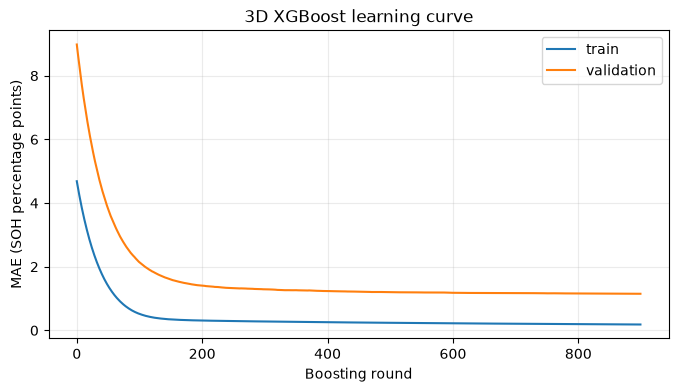

In [ ]:
history = model.evals_result()
plt.figure(figsize=(8, 4))
plt.plot(history["validation_0"]["mae"], label="train")
plt.plot(history["validation_1"]["mae"], label="validation")
plt.xlabel("Boosting round")
plt.ylabel("MAE (SOH percentage points)")
plt.title("3D XGBoost learning curve")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Final chronological test and quality gate

Tree models do not extrapolate degradation perfectly beyond the training range, so MAE is the primary metric. R² may be negative on the narrow, later-cycle test segment even when MAE improves materially over the operational baseline.

In [ ]:
test_predictions = np.clip(model.predict(X_test), 0.0, 100.0)
baseline_metrics = regression_metrics(y_test, baseline_test)
test_metrics = regression_metrics(y_test, test_predictions)
mae_improvement = 1.0 - test_metrics["mae_pct"] / baseline_metrics["mae_pct"]
quality_gate_passed = bool(
    test_metrics["mae_pct"] <= MAX_TEST_MAE_PCT
    and mae_improvement >= MIN_BASELINE_IMPROVEMENT
)

print("Baseline test:", baseline_metrics)
print("XGBoost test:", test_metrics)
print(f"MAE improvement: {mae_improvement:.2%}")
print("QUALITY GATE:", "PASS" if quality_gate_passed else "FAIL")

Baseline test: {'mae_pct': 3.6117758517795138, 'rmse_pct': 3.6694028754975108, 'r2': -31.08949719950622}
XGBoost test: {'mae_pct': 2.8481016159057617, 'rmse_pct': 2.9147311918661387, 'r2': -19.247394561767578}
MAE improvement: 21.14%
QUALITY GATE: PASS


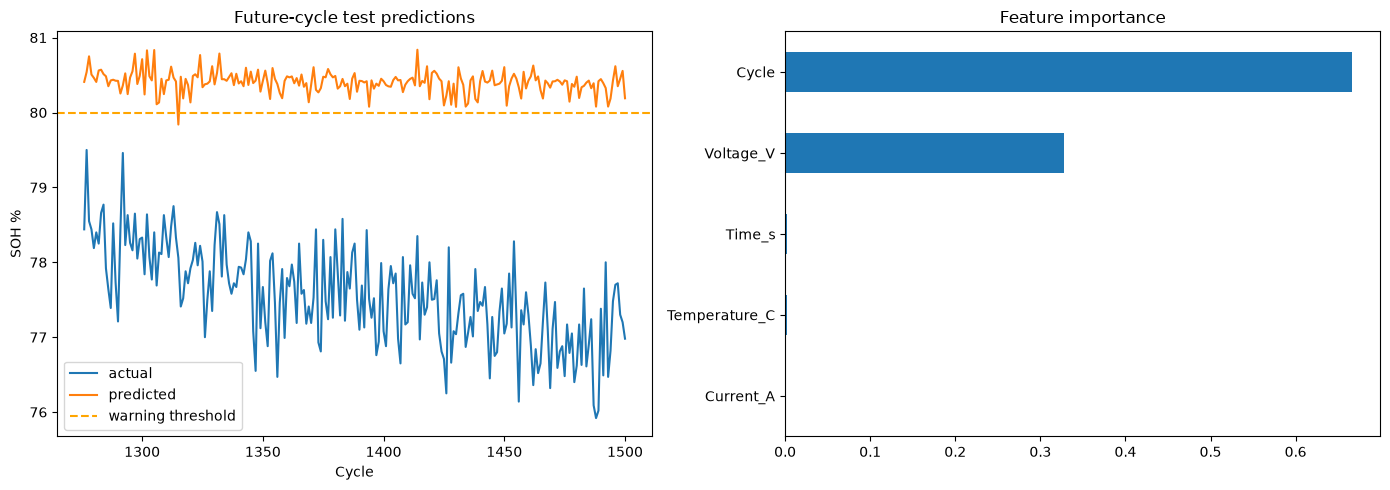

,importance
Cycle,0.665892
Voltage_V,0.328296
Time_s,0.002246
Temperature_C,0.002058
Current_A,0.001509


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(X_test["Cycle"], y_test, label="actual")
axes[0].plot(X_test["Cycle"], test_predictions, label="predicted")
axes[0].axhline(80, color="orange", linestyle="--", label="warning threshold")
axes[0].set(xlabel="Cycle", ylabel="SOH %", title="Future-cycle test predictions")
axes[0].legend()

importance = pd.Series(model.feature_importances_, index=BATTERY_SOH_FEATURES).sort_values()
importance.plot.barh(ax=axes[1])
axes[1].set_title("Feature importance")
plt.tight_layout()
plt.show()
display(importance.sort_values(ascending=False).to_frame("importance"))

## Refit all cycles and save

After honest chronological evaluation, refit with the selected number of trees on all available cycles. The artifact records test metrics and feature ranges. Runtime inference marks inputs outside those ranges.

In [ ]:
from datetime import datetime, timezone

if quality_gate_passed:
    selected_trees = int(model.best_iteration) + 1
    final_model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=selected_trees,
        max_depth=4,
        learning_rate=0.025,
        subsample=0.90,
        colsample_bytree=0.90,
        min_child_weight=3,
        reg_alpha=0.05,
        reg_lambda=1.5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
    )
    final_model.fit(X, y, verbose=False)
    feature_ranges = {
        feature: [float(X[feature].min()), float(X[feature].max())]
        for feature in BATTERY_SOH_FEATURES
    }
    bundle = {
        "schema_version": 1,
        "module": "3D",
        "task": "battery_soh_regression",
        "model": final_model,
        "features": list(BATTERY_SOH_FEATURES),
        "target": "SOH_pct",
        "feature_ranges": feature_ranges,
        "metrics": test_metrics,
        "baseline_metrics": baseline_metrics,
        "mae_improvement": float(mae_improvement),
        "evaluation": "chronological_70_15_15",
        "dataset": str(BATTERY_SOH_PATH),
        "rows": int(len(X)),
        "trained_at": datetime.now(timezone.utc).isoformat(),
        "versions": {
            "xgboost": xgboost.__version__,
            "scikit_learn": sklearn.__version__,
            "joblib": joblib.__version__,
        },
    }
    BATTERY_SOH_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(bundle, BATTERY_SOH_MODEL_PATH)
    print(f"Saved {BATTERY_SOH_MODEL_PATH} ({BATTERY_SOH_MODEL_PATH.stat().st_size / 1024:.1f} KiB)")
else:
    print("Artifact NOT saved: model failed the chronological quality gate.")

Saved F:\BMW\ml\models\battery_soh_xgb.joblib (1413.9 KiB)


In [ ]:
if quality_gate_passed:
    from ml.predictive_maintenance.battery_model import BatterySoHPredictor

    runtime = BatterySoHPredictor(model_path=BATTERY_SOH_MODEL_PATH)
    result = runtime.predict(X_test.iloc[-1].to_dict())
    print("Actual final test SOH:", float(y_test.iloc[-1]))
    print("Predicted:", result)
    print("3D artifact reload check passed.")
else:
    print("Reload skipped because no deployable artifact was created.")

Actual final test SOH: 76.9800033569336
Predicted: BatterySoHResult(soh_pct=77.1226577758789, severity='warning', maintenance_required=True, within_training_range=True)
3D artifact reload check passed.
